## Practice: Basic Artificial Neural Networks
Credits: this notebook belongs to [Practical DL](https://docs.google.com/forms/d/e/1FAIpQLScvrVtuwrHSlxWqHnLt1V-_7h2eON_mlRR6MUb3xEe5x9LuoA/viewform?usp=sf_link) course by Yandex School of Data Analysis.

We will start working with neural networks on the practice session. Your homework will be to finish the implementation of the layers.

Our goal is simple, yet an actual implementation may take some time :). We are going to write an Artificial Neural Network (almost) from scratch. The software design was heavily inspired by [PyTorch](http://pytorch.org) which is the main framework of our course

Speaking about the homework (once again, it will be really similar to this seminar), it requires sending **multiple** files, please do not forget to include all the files when sending to TA. The list of files:
- This notebook
- modules.ipynb with all blocks implemented (except maybe `Conv2d` and `MaxPool2d` layers implementation which are part of 'advanced' version of this homework)

In [1]:
%matplotlib inline
from time import time, sleep
import numpy as np
import matplotlib.pyplot as plt
from IPython import display

# Framework

Implement everything in `modules.ipynb`. Read all the comments thoughtfully to ease the pain. Please try not to change the prototypes.

Do not forget, that each module should return **AND** store `output` and `gradInput`.

The typical assumption is that `module.backward` is always executed after `module.forward`,
so `output` is stored, this would be useful for `SoftMax`.

### Tech note
Prefer using `np.multiply`, `np.add`, `np.divide`, `np.subtract` instead of `*`,`+`,`/`,`-` for better memory handling.

Example: suppose you allocated a variable

```
a = np.zeros(...)
```
So, instead of
```
a = b + c  # will be reallocated, GC needed to free
```
You can use:
```
np.add(b,c,out = a) # puts result in `a`
```

In [124]:
# (re-)load layers
%run modules.ipynb

<>:3: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipython-input-3092293347.py:3: SyntaxWarning: invalid escape sequence '\g'
  Implements linear transform of input y = \gamma * x + \beta


# Toy example

Use this example to debug your code, start with logistic regression and then test other layers. You do not need to change anything here. This code is provided for you to test the layers. Also it is easy to use this code in MNIST task.

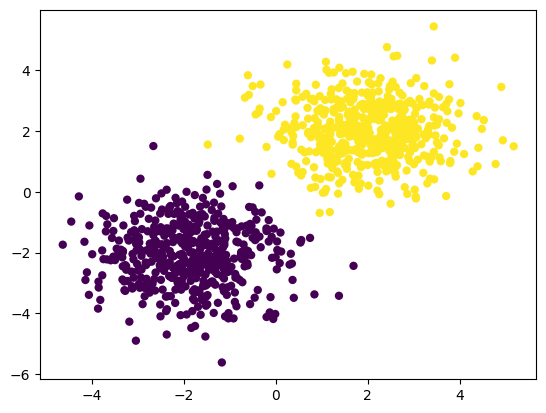

In [4]:
# Generate some data
N = 500

X1 = np.random.randn(N,2) + np.array([2,2])
X2 = np.random.randn(N,2) + np.array([-2,-2])

Y = np.concatenate([np.ones(N),np.zeros(N)])[:,None]
Y = np.hstack([Y, 1-Y])

X = np.vstack([X1,X2])
plt.scatter(X[:,0],X[:,1], c = Y[:,0], edgecolors= 'none')

Define a **logistic regression** for debugging.

In [5]:
net = Sequential()
net.add(Linear(2, 2))
net.add(LogSoftMax())

criterion = ClassNLLCriterion()

print(net)

# Test something like that then

# net = Sequential()
# net.add(Linear(2, 4))
# net.add(ReLU())
# net.add(Linear(4, 2))
# net.add(LogSoftMax())

Linear 2 -> 2
LogSoftMax



In [6]:
net = Sequential()
net.add(Linear(2, 4))
net.add(ReLU())
net.add(Linear(4, 2))
net.add(LogSoftMax())
print(net)

Linear 2 -> 4
ReLU
Linear 4 -> 2
LogSoftMax



Start with batch_size = 1000 to make sure every step lowers the loss, then try stochastic version.

In [11]:
# Iptimizer params
optimizer_config = {'learning_rate' : 1e-1, 'momentum': 0.9}
optimizer_state = {}

# Looping params
n_epoch = 20
batch_size = 128

In [12]:
# batch generator
def get_batches(dataset, batch_size):
    X, Y = dataset
    n_samples = X.shape[0]

    # Shuffle at the start of epoch
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)

        batch_idx = indices[start:end]

        yield X[batch_idx], Y[batch_idx]

### Train

Basic training loop. Examine it.

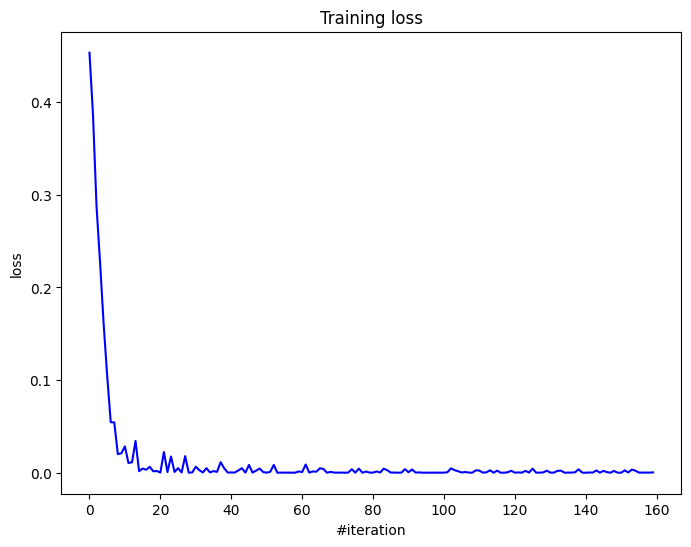

Current loss: 0.000362


In [11]:
loss_history = []

for i in range(n_epoch):
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        net.zeroGradParameters()

        # Forward
        predictions = net.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        net.backward(x_batch, dp)

        # Update weights
        sgd_momentum(net.getParameters(),
                     net.getGradParameters(),
                     optimizer_config,
                     optimizer_state)

        loss_history.append(loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss)

# Digit classification

We are using old good [MNIST](http://yann.lecun.com/exdb/mnist/) as our dataset. It can be downloaded with the following file.

In [12]:
!wget https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py -nc

--2025-12-14 17:07:26--  https://raw.githubusercontent.com/girafe-ai/ml-course/23f_basic/homeworks/hw08_nn_from_scratch/mnist.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2697 (2.6K) [text/plain]
Saving to: ‘mnist.py’

mnist.py            100%[===================>]   2.63K  --.-KB/s    in 0s      

2025-12-14 17:07:26 (52.9 MB/s) - ‘mnist.py’ saved [2697/2697]



In [14]:
import mnist
X_train, y_train, X_val, y_val, X_test, y_test = mnist.load_dataset()

HTTPError: HTTP Error 404: Not Found

In [21]:
!wget http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz

--2025-12-14 17:23:17--  http://yann.lecun.com/exdb/mnist/train-images-idx3-ubyte.gz
Resolving yann.lecun.com (yann.lecun.com)... 15.204.224.156
Connecting to yann.lecun.com (yann.lecun.com)|15.204.224.156|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-12-14 17:23:17 ERROR 404: Not Found.



In [2]:
from tensorflow.keras.datasets import mnist


def load_dataset():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # We reserve the last 10000 training examples for validation.
    X_train, X_val = X_train[:-10000], X_train[-10000:]
    y_train, y_val = y_train[:-10000], y_train[-10000:]


    return X_train, y_train, X_val, y_val, X_test, y_test

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
y_train[0].dtype

dtype('uint8')

In [10]:
X_train.shape

(50000, 28, 28)

One-hot encode the labels first.

In [ ]:
# Your code goes here. ################################################

In [6]:
n_classes = 10
y_train = np.eye(n_classes)[y_train]
y_val = np.eye(n_classes)[y_val]
y_test = np.eye(n_classes)[y_test]

In [18]:
input_size = X_train.shape[1] * X_train.shape[2]
input_size

784

- **Compare** `ReLU`, `ELU`, `LeakyReLU`, `SoftPlus` activation functions.
You would better pick the best optimizer params for each of them, but it is overkill for now. Use an architecture of your choice for the comparison.
- **Try** inserting `BatchNormalization` (folowed by `ChannelwiseScaling`) between `Linear` module and activation functions.
- Plot the losses both from activation functions comparison and `BatchNormalization` comparison on one plot. Please find a scale (log?) when the lines are distinguishable, do not forget about naming the axes, the plot should be goodlooking.
- Plot the losses for two networks: one trained by momentum_sgd, another one trained by Adam. Which one performs better?
- Hint: good logloss for MNIST should be around 0.5.

Write your personal opinion on the activation functions, think about computation times too. Does `BatchNormalization` help?

In [76]:
import time

def train(model, X, Y, X_val, Y_val, num_epochs, batch_size, criterion, optimizer, optimizer_config, optimizer_state = {}):
  print("Start training...")
  history = []
  val_history = []
  train_history = []

  n_samples_train = X.shape[0]
  batches_per_epoch = int(np.ceil(n_samples_train / batch_size))

  training_start_time = time.time()
  for epoch in range(num_epochs):
    model.train()
    for x_batch, y_batch in get_batches((X, Y), batch_size):

        model.zeroGradParameters()

        # Forward
        predictions = model.forward(x_batch)
        loss = criterion.forward(predictions, y_batch)

        # Backward
        dp = criterion.backward(predictions, y_batch)
        model.backward(x_batch, dp)

        # Update weights
        optimizer(variables=model.getParameters(),
                  gradients=model.getGradParameters(),
                  config=optimizer_config,
                  state=optimizer_state)

        history.append(loss)

    train_history.append(loss)
    model.evaluate()
    y_val_pred = model.forward(X_val)
    val_loss = criterion.forward(y_val_pred, Y_val)
    val_history.append(val_loss)

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title(f"Training and Validation loss (Epoch {epoch+1})")
    plt.xlabel("#iteration")
    plt.ylabel("loss")

    plt.plot(history, 'b', label='Training loss')

    x_val_plot_indices = [(i + 1) * batches_per_epoch - 1 for i in range(len(val_history))]
    plt.plot(x_val_plot_indices, val_history, 'r', label='Validation loss')
    plt.legend()
    plt.show()

    print('Current training loss: %f' % loss)
    print('Current validation loss: %f' % val_loss)

  training_end_time = time.time() # End timing for the epoch
  total_time = training_end_time - training_start_time
  print('Training time: %.2f seconds' % (total_time))

  return train_history, val_history, total_time

### Different activations

In [125]:
# Iptimizer params
SGD_CONFIG = {'learning_rate' : 1e-1, 'momentum': 0.9}
ADAM_CONFIG = {'learning_rate' : 1e-3, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}

In [126]:
model_list = []
for activation_name in ['ReLU', 'ELU', 'LeakyReLU', 'SoftPlus']:
  net = Sequential()
  net.add(Linear(input_size, 64))

  activation_class = globals()[activation_name]
  net.add(activation_class())

  net.add(Linear(64, n_classes))
  net.add(LogSoftMax())
  model_list.append(net)

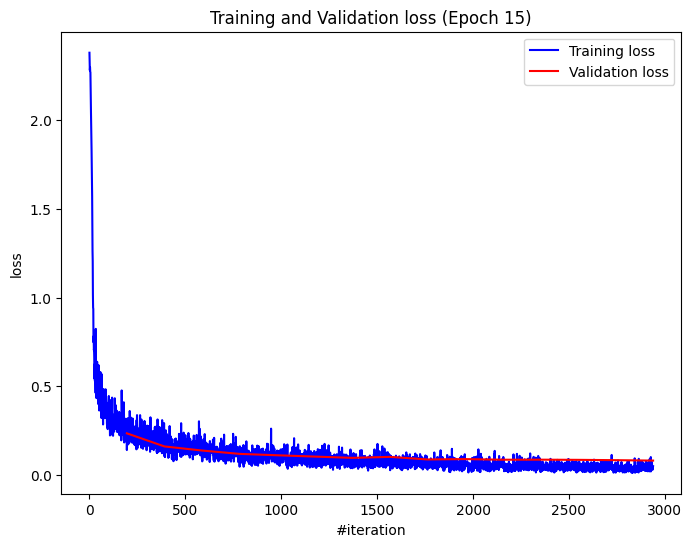

Current training loss: 0.049760
Current validation loss: 0.081516
Training time: 10.61 seconds


In [127]:
history = []
for i in range(len(model_list)):
  h = train(model=model_list[i],
            X=X_train.reshape([len(X_train), -1]),
            Y=y_train,
            X_val=X_val.reshape([len(X_val), -1]),
            Y_val=y_val,
            num_epochs=15,
            criterion=ClassNLLCriterion(),
            batch_size=256,
            optimizer=sgd_momentum,
            optimizer_config=SGD_CONFIG,
            optimizer_state={},
            )
  history.append(h)

(ReLU) train time: 7.578167915344238
(ELU) train time: 10.708459854125977
(LeakyReLU) train time: 9.37902045249939
(SoftPlus) train time: 10.611167430877686


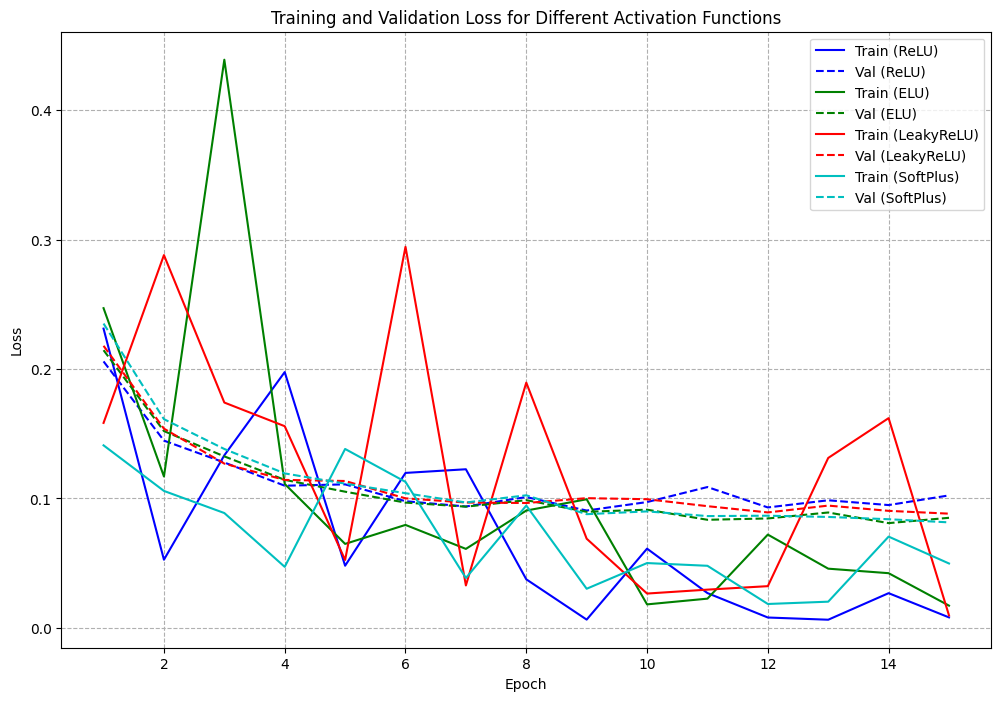

In [128]:
plt.figure(figsize=(12, 8))
plt.title("Training and Validation Loss for Different Activation Functions")
plt.xlabel("Epoch")
plt.ylabel("Loss")

colors=['b', 'g', 'r', 'c']

# Assuming activation_names corresponds to the order in which models were trained and added to losses_history
activation_names = ['ReLU', 'ELU', 'LeakyReLU', 'SoftPlus']

for i, (train_hist, val_hist, time_total) in enumerate(history):
    current_activation_name = activation_names[i]
    epochs = np.arange(1, len(train_hist) + 1)

    plt.plot(epochs, train_hist, label=f'Train ({current_activation_name})', linestyle='-', color=colors[i])
    plt.plot(epochs, val_hist, label=f'Val ({current_activation_name})', linestyle='--', color=colors[i])
    print(f'({current_activation_name}) train time: {time_total}')


plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Вывод:
1) Все модели начали переобучаться после 10 эпохи
2) Наиболее стабильная и с лучшим лоссом на валидации тренировка с ReLu, остальных сильно штормит и они сходятся медленнее


### BatchNorm test

In [147]:
model_list2 = []
for activation_name in ['ReLU', 'ELU', 'LeakyReLU', 'SoftPlus']:
  net = Sequential()
  net.add(Linear(input_size, 64))

  net.add(BatchNormalization())
  net.add(ChannelwiseScaling(64))

  activation_class = globals()[activation_name]
  net.add(activation_class())

  net.add(Linear(64, n_classes))

  net.add(BatchNormalization())
  net.add(ChannelwiseScaling(n_classes))

  net.add(LogSoftMax())

  model_list2.append(net)

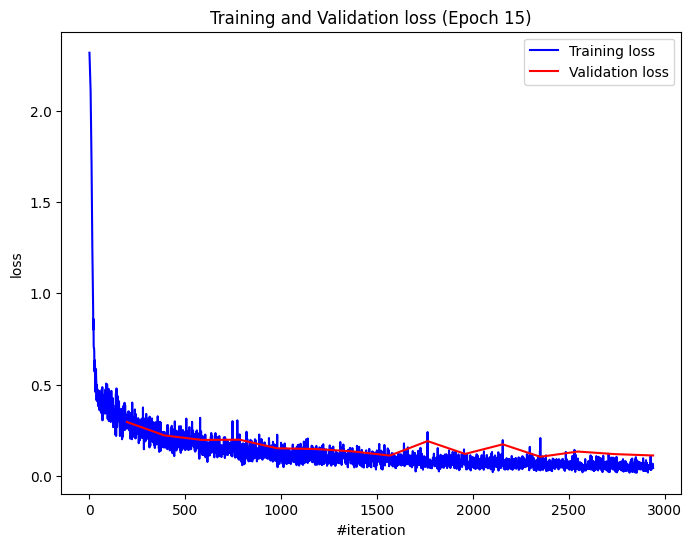

Current training loss: 0.041925
Current validation loss: 0.110694
Training time: 15.25 seconds


In [130]:
history2 = []
for i in range(len(model_list2)):
  h = train(model=model_list2[i],
            X=X_train.reshape([len(X_train), -1]),
            Y=y_train,
            X_val=X_val.reshape([len(X_val), -1]),
            Y_val=y_val,
            num_epochs=15,
            criterion=ClassNLLCriterion(),
            batch_size=256,
            optimizer=sgd_momentum,
            optimizer_config=SGD_CONFIG,
            optimizer_state = {},
            )
  history2.append(h)

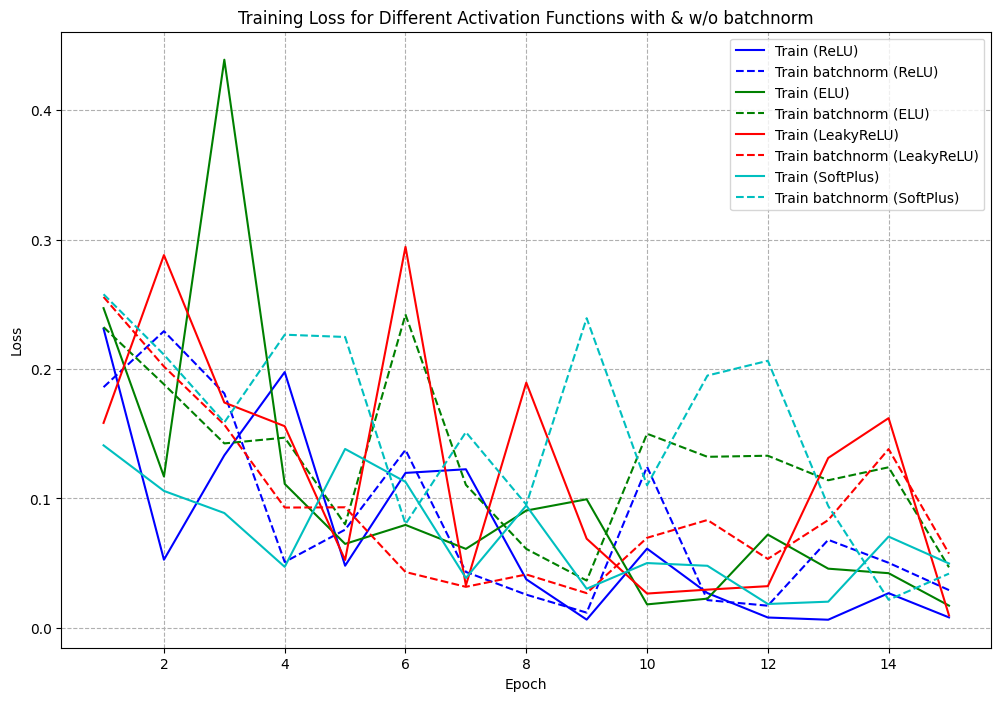

In [141]:
plt.figure(figsize=(12, 8))
plt.title("Training Loss for Different Activation Functions with & w/o batchnorm")
plt.xlabel("Epoch")
plt.ylabel("Loss")

colors=['b', 'g', 'r', 'c']

# Assuming activation_names corresponds to the order in which models were trained and added to losses_history
activation_names = ['ReLU', 'ELU', 'LeakyReLU', 'SoftPlus']

for i in range(len(history)):
    train_hist, val_hist, _ = history[i]
    train_hist2, val_hist2, _ = history2[i]
    current_activation_name = activation_names[i]
    epochs = np.arange(1, len(train_hist) + 1)

    plt.plot(epochs, train_hist, label=f'Train ({current_activation_name})', linestyle='-', color=colors[i])
    plt.plot(epochs, train_hist2, label=f'Train batchnorm ({current_activation_name})', linestyle='--', color=colors[i])


plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

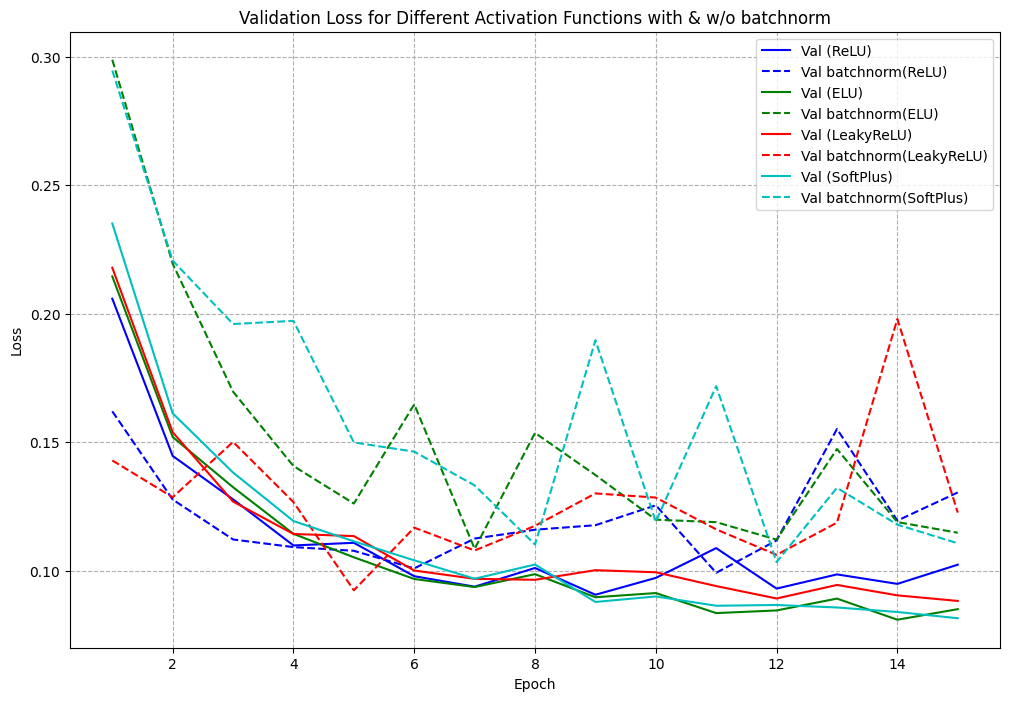

In [142]:
plt.figure(figsize=(12, 8))
plt.title("Validation Loss for Different Activation Functions with & w/o batchnorm")
plt.xlabel("Epoch")
plt.ylabel("Loss")
for i in range(len(history)):
    train_hist, val_hist, _ = history[i]
    train_hist2, val_hist2, _ = history2[i]
    current_activation_name = activation_names[i]
    epochs = np.arange(1, len(train_hist) + 1)

    plt.plot(epochs, val_hist, label=f'Val ({current_activation_name})', linestyle='-', color=colors[i])
    plt.plot(epochs, val_hist2, label=f'Val batchnorm({current_activation_name})', linestyle='--', color=colors[i])


plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Вывод:
1) C BatchNorm ReLu, LeakyReLu стали сходиться немного плавнее

### Сравнение моделей с Adam и SGD

In [153]:
SGD_CONFIG = {'learning_rate' : 1e-3, 'momentum': 0.9}
ADAM_CONFIG = {'learning_rate' : 1e-3, 'beta1': 0.9, 'beta2': 0.999, 'epsilon': 1e-8}

In [154]:
net = Sequential()
net.add(Linear(input_size, 64))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(64))

net.add(ReLU())

net.add(Linear(64, n_classes))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(n_classes))

net.add(LogSoftMax())

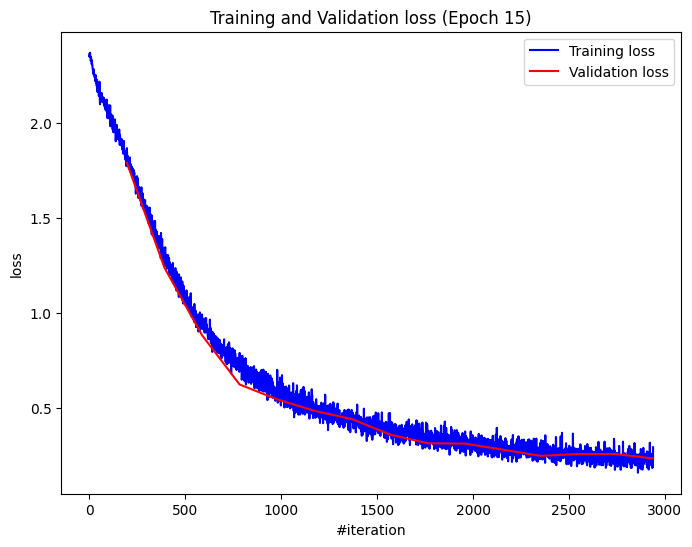

Current training loss: 0.292925
Current validation loss: 0.233981
Training time: 11.45 seconds


In [155]:
h1 = train(model=net,
          X=X_train.reshape([len(X_train), -1]),
          Y=y_train,
          X_val=X_val.reshape([len(X_val), -1]),
          Y_val=y_val,
          num_epochs=15,
          criterion=ClassNLLCriterion(),
          batch_size=256,
          optimizer=sgd_momentum,
          optimizer_config=SGD_CONFIG,
          optimizer_state = {},
          )


In [156]:
net = Sequential()
net.add(Linear(input_size, 64))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(64))

net.add(ReLU())

net.add(Linear(64, n_classes))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(n_classes))

net.add(LogSoftMax())

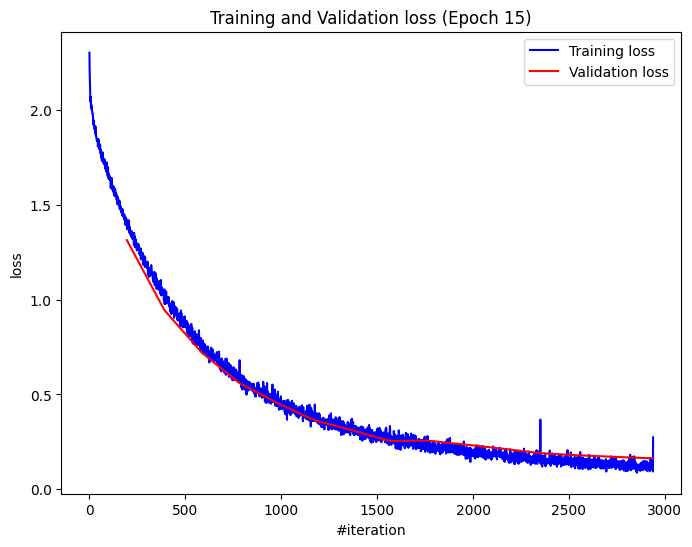

Current training loss: 0.273758
Current validation loss: 0.163263
Training time: 11.59 seconds


In [157]:
h2 = train(model=net,
          X=X_train.reshape([len(X_train), -1]),
          Y=y_train,
          X_val=X_val.reshape([len(X_val), -1]),
          Y_val=y_val,
          num_epochs=15,
          criterion=ClassNLLCriterion(),
          batch_size=256,
          optimizer=adam_optimizer,
          optimizer_config=ADAM_CONFIG,
          optimizer_state = {},
          )


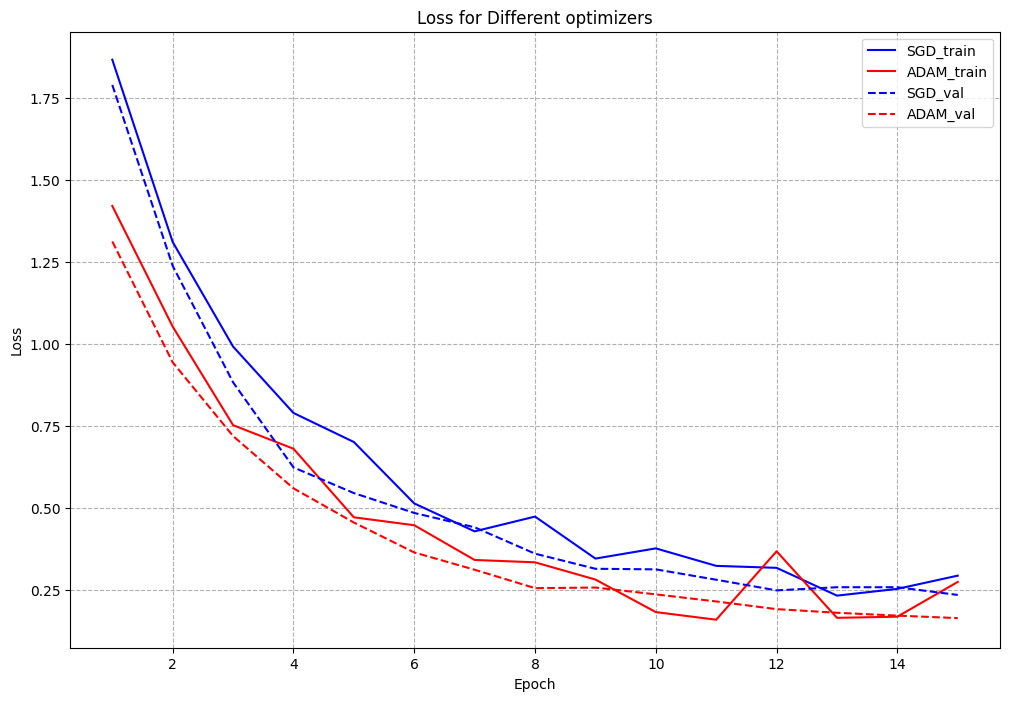

In [161]:
plt.figure(figsize=(12, 8))
plt.title("Loss for Different optimizers")
plt.xlabel("Epoch")
plt.ylabel("Loss")

train_hist, val_hist, _ = h1
train_hist2, val_hist2, _ = h2

epochs = np.arange(1, len(train_hist) + 1)

plt.plot(epochs, train_hist, label=f'SGD_train', linestyle='-', color=colors[0])
plt.plot(epochs, train_hist2, label=f'ADAM_train', linestyle='-', color=colors[2])

plt.plot(epochs, val_hist, label=f'SGD_val', linestyle='--', color=colors[0])
plt.plot(epochs, val_hist2, label=f'ADAM_val', linestyle='--', color=colors[2])


plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Вывод:
1) C Adam лучше сходится

**Finally**, use all your knowledge to build a super cool model on this dataset. Use **dropout** to prevent overfitting, play with **learning rate decay**. You can use **data augmentation** such as rotations, translations to boost your score. Use your knowledge and imagination to train a model. Don't forget to call `training()` and `evaluate()` methods to set desired behaviour of `BatchNormalization` and `Dropout` layers.

In [163]:
net = Sequential()
net.add(Linear(input_size, 128))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(128))
net.add(ReLU())
net.add(Dropout(0.2))

net.add(Linear(128, n_classes))

net.add(BatchNormalization())
net.add(ChannelwiseScaling(n_classes))
net.add(LogSoftMax())

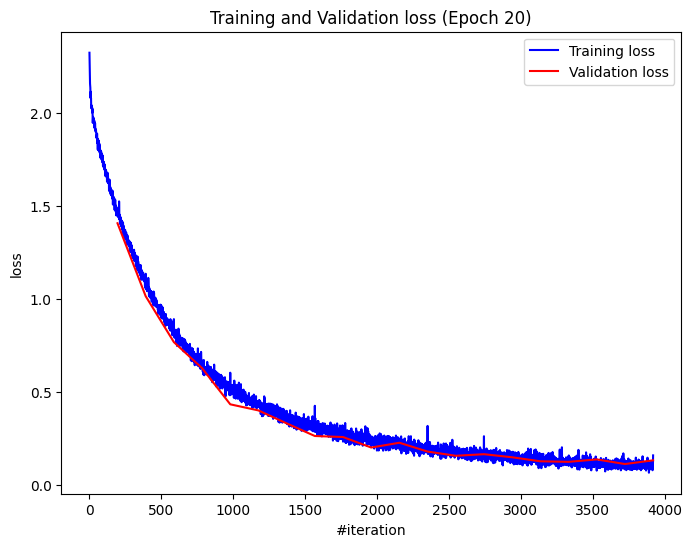

Current training loss: 0.159319
Current validation loss: 0.132759
Training time: 23.01 seconds


In [164]:
h3 = train(model=net,
          X=X_train.reshape([len(X_train), -1]),
          Y=y_train,
          X_val=X_val.reshape([len(X_val), -1]),
          Y_val=y_val,
          num_epochs=20,
          criterion=ClassNLLCriterion(),
          batch_size=256,
          optimizer=adam_optimizer,
          optimizer_config=ADAM_CONFIG,
          optimizer_state = {},
          )



In [187]:
def accuracy(log_probs, targets):
    if isinstance(log_probs, torch.Tensor):
        preds = np.argmax(log_probs.detach().numpy(), axis=1)
    else:
        preds = np.argmax(log_probs, axis=1)
    return np.mean(preds == targets) * 100

In [168]:
net.evaluate()
log_probs = net.forward(X_test.reshape([len(X_test), -1]))
accuracy(log_probs, np.argmax(y_test, axis=1))

np.float64(96.78)

In [ ]:
# Your code goes here. ################################################

Print here your accuracy on test set. It should be around 90%.

In [ ]:
# Your answer goes here. ################################################

### Comparing with PyTorch implementation
The last (and maybe the easiest step after compared to the previous tasks: build a network with the same architecture as above now with PyTorch.

You can refer to the `week0_09` or `Lab3_part2` notebooks for hints.

__Good Luck!__

In [ ]:
# Your beautiful code here.

In [174]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [172]:
class PyTorchNet(nn.Module):
    def __init__(self, input_size, n_classes):
        super(PyTorchNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)

        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(128, n_classes)
        self.bn2 = nn.BatchNorm1d(n_classes)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.logsoftmax(x)
        return x

In [179]:
pytorch_model = PyTorchNet(input_size, n_classes)
print(pytorch_model)

PyTorchNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (bn2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (logsoftmax): LogSoftmax(dim=1)
)


In [180]:
def train_pytorch_model(model, X, Y, X_val, Y_val, num_epochs, batch_size, criterion, optimizer):
  print("Start training...")
  history = []
  train_epoch_losses = []
  val_epoch_losses = []

  n_samples_train = X.shape[0]
  batches_per_epoch = int(np.ceil(n_samples_train / batch_size))

  training_start_time = time.time()
  for epoch in range(num_epochs):
    model.train()
    current_epoch_batch_losses = []

    for x_batch_np, y_batch_np in get_batches((X, Y), batch_size):
        x_batch_tensor = torch.from_numpy(x_batch_np).float()
        y_batch_tensor = torch.from_numpy(np.argmax(y_batch_np, axis=1)).long()

        optimizer.zero_grad()

        # Forward pass
        predictions = model(x_batch_tensor)
        loss = criterion(predictions, y_batch_tensor)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        history.append(loss.item()) # Store batch training loss
        current_epoch_batch_losses.append(loss.item())

    train_epoch_losses.append(np.mean(current_epoch_batch_losses)) # Store average epoch training loss

    # Validation phase
    model.eval()
    with torch.no_grad():
        x_val_tensor = torch.from_numpy(X_val).float()
        y_val_tensor = torch.from_numpy(np.argmax(Y_val, axis=1)).long()

        y_val_pred = model(x_val_tensor)
        val_loss = criterion(y_val_pred, y_val_tensor)
        val_epoch_losses.append(val_loss.item())

    # Visualize
    display.clear_output(wait=True)
    plt.figure(figsize=(10, 6))

    plt.title(f"Training and Validation loss (Epoch {epoch+1})")
    plt.xlabel("Iteration (Batches)")
    plt.ylabel("Loss")

    plt.plot(history, 'b', label='Training loss (Batch)')

    x_val_plot_indices = [(i + 1) * batches_per_epoch - 1 for i in range(len(val_epoch_losses))]
    plt.plot(x_val_plot_indices, val_epoch_losses, 'r-o', label='Validation loss (Epoch)', markersize=5)

    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.show()

    print('Current training loss (Epoch Avg): %f' % train_epoch_losses[-1])
    print('Current validation loss: %f' % val_epoch_losses[-1])

  training_end_time = time.time()
  total_time = training_end_time - training_start_time
  print('Training time: %.2f seconds' % (total_time))

  return train_epoch_losses, val_epoch_losses, total_time


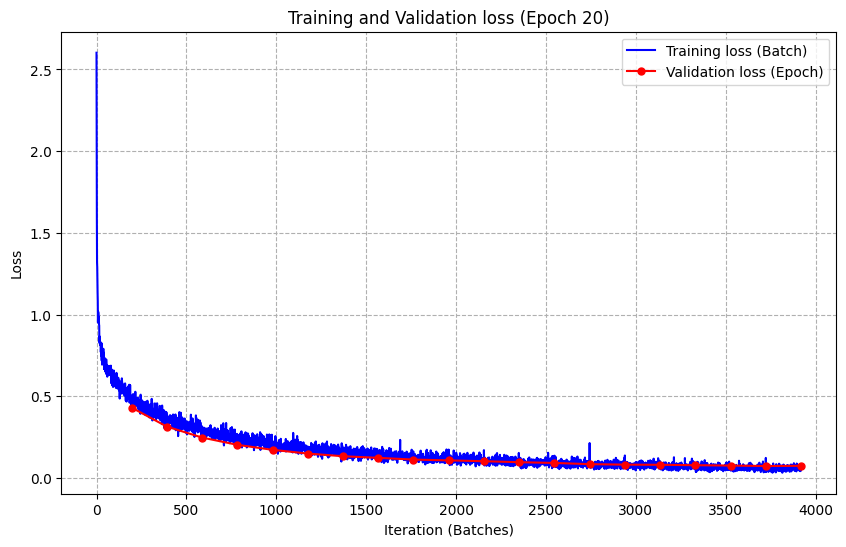

Current training loss (Epoch Avg): 0.058177
Current validation loss: 0.074250
Training time: 13.12 seconds


In [181]:
h4 = train_pytorch_model(pytorch_model,
                          X=X_train.reshape([len(X_train), -1]),
                          Y=y_train,
                          X_val=X_val.reshape([len(X_val), -1]),
                          Y_val=y_val,
                          num_epochs=20,
                          criterion=nn.NLLLoss(),
                          batch_size=256,
                          optimizer=optim.Adam(pytorch_model.parameters(), lr=0.001)
                          )

In [188]:
pytorch_model.eval()
# Convert X_test to a PyTorch tensor before passing it to the model
log_probs2 = pytorch_model.forward(torch.from_numpy(X_test.reshape([len(X_test), -1])).float())
accuracy(log_probs2, np.argmax(y_test, axis=1))

np.float64(98.08)

Вывод:
1) Результаты получились близкие (accuracy 97 vs 98), у pytorch лучше
1) pytorch работает в 2 раза быстрее